In [1]:
# import os, sys
# project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
# if project_root not in sys.path:
#     sys.path.append(project_root)
# from agents.hotel.agent import hotel_graph as graph
import os, sys
import uuid
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import hàm build graph thay vì import graph trực tiếp
# from agents.hotel.agent import hotel_graph as graph 
from agents.hotel.agent import build_hotel_graph 
from utils.tracing import with_trace_config

# Khởi tạo graph (cần dùng await vì hàm này là async)
graph = await build_hotel_graph()

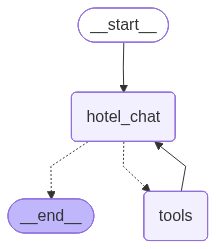

In [2]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [2]:
# def stream_graph_updates(inputs: dict):
#     for event in graph.stream(inputs):
#         if "hotel_chat" in event:
#             messages = event["hotel_chat"].get("messages", [])
#             for msg in messages:
#                 # Nếu là AIMessage (object)
#                 if hasattr(msg, "content") and msg.content:
#                     print("Assistant:", msg.content)
#                 # Nếu là dict
#                 elif isinstance(msg, dict) and msg.get("role") == "assistant":
#                     print("Assistant:", msg.get("content"))
#         if "tools" in event:
#             messages = event["tools"].get("messages", [])
#             for msg in messages:
#                 if hasattr(msg, "content") and msg.content:
#                     print("Tool Output:", msg.content)
#                 elif isinstance(msg, dict):
#                     print("Tool Output:", msg.get("content"))
# async def stream_graph_updates(inputs: dict):
#     async for event in graph.astream(inputs):
#         if "hotel_chat" in event:
#             messages = event["hotel_chat"].get("messages", [])
#             for msg in messages:
#                 if hasattr(msg, "content") and msg.content:
#                     print("Assistant:", msg.content)
#                 elif isinstance(msg, dict) and msg.get("role") == "assistant":
#                     print("Assistant:", msg.get("content"))

#         if "tools" in event:
#             messages = event["tools"].get("messages", [])
#             for msg in messages:
#                 if hasattr(msg, "content") and msg.content:
#                     print("Tool Output:", msg.content)
#                 elif isinstance(msg, dict):
#                     print("Tool Output:", msg.get("content"))
from langchain_core.messages import AIMessage

async def stream_graph_updates(inputs: dict):
    thread_id = str(uuid.uuid4())
    config = with_trace_config(
        {"configurable": {"thread_id": thread_id}},
        run_name="hotel_agent_notebook",
        tags=["customer-support", "hotel", "notebook"],
        metadata={"thread_id": thread_id, "agent": "hotel"},
    )

    async for event in graph.astream(inputs, config=config):
        if "hotel_chat" in event:
            for msg in event["hotel_chat"].get("messages", []):
                # In tham số tool — đây là chỗ cần check
                if isinstance(msg, AIMessage) and msg.tool_calls:
                    for tc in msg.tool_calls:
                        print("🔧 Tool:", tc["name"])
                        print("📥 Args:", tc["args"])

                if hasattr(msg, "content") and msg.content:
                    print("Assistant:", msg.content)

        if "tools" in event:
            for msg in event["tools"].get("messages", []):
                if hasattr(msg, "content") and msg.content:
                    print("Tool Output:", msg.content)

In [3]:
test_cases = [
    "Khách sạn nào mà cách trung tâm gần á. Tìm kiếm khách sạn ở Hà Nội,  giá thấp nhất là 2 triệu, rating trên 9.0, cho 4 người lớn, check in 20/9/2026 và check out 25/9/2026.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)



🧑‍💻 User: Khách sạn nào mà cách trung tâm gần á. Tìm kiếm khách sạn ở Hà Nội,  giá thấp nhất là 2 triệu, rating trên 9.0, cho 4 người lớn, check in 20/9/2026 và check out 25/9/2026.
{'messages': [{'role': 'user', 'content': 'Khách sạn nào mà cách trung tâm gần á. Tìm kiếm khách sạn ở Hà Nội,  giá thấp nhất là 2 triệu, rating trên 9.0, cho 4 người lớn, check in 20/9/2026 và check out 25/9/2026.'}]}
🔧 Tool: search_hotels_tool
📥 Args: {'rating': 9, 'adults': 4, 'checkout_date': '2026-09-25', 'location': 'Hà Nội', 'price_min': 2000000, 'checkin_date': '2026-09-20'}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "booking_com15_rapidapi",\n  "external_hotel_id": 16953681,\n  "booking_link": "https://www.booking.com/hotel/index.vi.html?dest_id=16953681&dest_type=hotel&checkin=2026-09-20&checkout=2026-09-25&group_adults=4&no_rooms=1",\n  "name": "Vinhomes Skylake My Dinh - Amie Housing",\n  "accessibilityLabel": [\n    "Vinhomes Skylake My Dinh - Amie Housing",\n    "10 Xuất sắc 1 đán

In [3]:
test_cases = [
    "Tìm kiếm khách sạn ở Đà Nẵng, 2 người lớn, có 1 trẻ em 16 tuổi, check in 20/8/2026, check out 22/8/2026. ",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)


🧑‍💻 User: Tìm kiếm khách sạn ở Đà Nẵng, 2 người lớn, có 1 trẻ em 16 tuổi, check in 20/8/2026, check out 22/8/2026. 
{'messages': [{'role': 'user', 'content': 'Tìm kiếm khách sạn ở Đà Nẵng, 2 người lớn, có 1 trẻ em 16 tuổi, check in 20/8/2026, check out 22/8/2026. '}]}
🔧 Tool: search_hotels_tool
📥 Args: {'checkin_date': '2026-08-20', 'location': 'Đà Nẵng', 'checkout_date': '2026-08-22', 'adults': 2, 'children_age': '16'}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "booking_com15_rapidapi",\n  "external_hotel_id": 17049599,\n  "name": "DiStay Times Square",\n  "accessibilityLabel": [\n    "DiStay Times Square",\n    "4 trên 5 cho xếp hạng chỗ nghỉ",\n    "8,7 Tuyệt vời 3 đánh giá",\n    "2,7km từ trung tâm",\n    "Giáp biển",\n    "Ưu Đãi Mùa Du Lịch",\n    "1 căn hộ nguyên căn – 48\xa0m² : 1\xa0giường • 1\xa0phòng ngủ • 1\xa0phòng khách • 1\xa0phòng tắm",\n    "Giá gốc là 17505000 VND",\n    "Giá hiện tại là 7002000 VND",\n    "Đã bao gồm thuế và phí",\n    "Hủy miễn phí",\n

In [ ]:
test_cases = [
    "Tìm kiếm khách sạn ở Phú Yên, giá là 2 triệu VND, đánh giá trên 8, 2 người lớn, ccheck in 20/9/2026, check out 22/9/2026. ",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)


🧑‍💻 User: Tìm kiếm khách sạn ở Phú Yên, giá là 2 triệu VND, đánh giá trên 8, 2 người lớn, ccheck in 20/9/2026, check out 22/9/2026. 
{'messages': [{'role': 'user', 'content': 'Tìm kiếm khách sạn ở Phú Yên, giá là 2 triệu VND, đánh giá trên 8, 2 người lớn, ccheck in 20/9/2026, check out 22/9/2026. '}]}
🔧 Tool: search_hotels_tool
📥 Args: {'adults': 2.0, 'checkout_date': '2026-09-22', 'checkin_date': '2026-09-20', 'rating': 8.0, 'price_max': 2000000.0, 'location': 'Phú Yên'}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "booking_com15_rapidapi",\n  "external_hotel_id": 10359444,\n  "name": "PAMY Homestay Phú Yên",\n  "location": "Phu Yen",\n  "rating": 9.2,\n  "rating_word": "Tuyệt hảo",\n  "review_count": 86,\n  "star": 0,\n  "price": 765000,\n  "price_per_night": 765000,\n  "total_price": 1530000,\n  "currency": "VND",\n  "price_tier": "mid",\n  "latitude": 13.0046986391415,\n  "longitude": 109.356032579132,\n  "photo": "https://cf.bstatic.com/xdata/images/hotel/square500/8477

In [ ]:
test_cases = [
    "Tìm kiếm khách sạn ở Nha Trang, giá cao nhất là 2 triệu VND, đánh giá trên 9, 2 người lớn, có 1 trẻ em 5 tuổi, ccheck in 20/9/2026, check out 22/9/2026. ",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)


🧑‍💻 User: Tìm kiếm khách sạn ở Nha Trang, giá cao nhất là 2 triệu VND, đánh giá trên 9, 2 người lớn, có 1 trẻ em 5 tuổi, ccheck in 20/9/2026, check out 22/9/2026. 
{'messages': [{'role': 'user', 'content': 'Tìm kiếm khách sạn ở Nha Trang, giá cao nhất là 2 triệu VND, đánh giá trên 9, 2 người lớn, có 1 trẻ em 5 tuổi, ccheck in 20/9/2026, check out 22/9/2026. '}]}
🔧 Tool: search_hotels_tool
📥 Args: {'adults': 2.0, 'checkin_date': '20/09/2026', 'price_max': 2000000.0, 'rating': 9.0, 'checkout_date': '22/09/2026', 'children_age': '5', 'location': 'Nha Trang'}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "booking_com15_rapidapi",\n  "external_hotel_id": 16256042,\n  "name": "WYNNE Hotel Nha Trang",\n  "location": "Nha Trang",\n  "rating": 9,\n  "rating_word": "Tuyệt hảo",\n  "review_count": 33,\n  "star": 4,\n  "price": 609840,\n  "price_per_night": 609840,\n  "total_price": 1219680,\n  "currency": "VND",\n  "price_tier": "budget",\n  "latitude": 12.2335875454929,\n  "longitude":

In [ ]:
test_cases = [
    "Tìm kiếm khách sạn ở Huế, giá hạng sang, đánh giá trên 8, 2 người lớn, có 1 trẻ em 5 tuổi, ccheck in 20/9/2026, check out 22/9/2026. ",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)


🧑‍💻 User: Tìm kiếm khách sạn ở Huế, giá hạng sang, đánh giá trên 8, 2 người lớn, có 1 trẻ em 5 tuổi, ccheck in 20/9/2026, check out 22/9/2026. 
{'messages': [{'role': 'user', 'content': 'Tìm kiếm khách sạn ở Huế, giá hạng sang, đánh giá trên 8, 2 người lớn, có 1 trẻ em 5 tuổi, ccheck in 20/9/2026, check out 22/9/2026. '}]}
🔧 Tool: search_hotels_tool
📥 Args: {'adults': 2.0, 'checkin_date': '2026-09-20', 'price_tier': 'luxury', 'rating': 8.0, 'children_age': '5', 'checkout_date': '2026-09-22', 'location': 'Huế'}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "booking_com15_rapidapi",\n  "external_hotel_id": 3990894,\n  "name": "Meliá Vinpearl Hue",\n  "location": "Huế",\n  "rating": 9.5,\n  "rating_word": "Xuất sắc",\n  "review_count": 4241,\n  "star": 5,\n  "price": 2099725,\n  "price_per_night": 2099725,\n  "total_price": 4199450,\n  "currency": "VND",\n  "price_tier": "luxury",\n  "latitude": 16.4630653589752,\n  "longitude": 107.594393985285,\n  "photo": "https://cf.bstatic.

In [4]:
test_cases = [
    "Tôi muốn xem phòng ở khách sạn có ID là 266027, check in 27/7/2026, check out 29/7/2026, cho 2 người lớn.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn xem phòng ở khách sạn có ID là 266027, check in 27/7/2026, check out 29/7/2026, cho 2 người lớn.
{'messages': [{'role': 'user', 'content': 'Tôi muốn xem phòng ở khách sạn có ID là 266027, check in 27/7/2026, check out 29/7/2026, cho 2 người lớn.'}]}


In [3]:
test_cases = [
    "Tìm kiếm khách sạn ở Huế, giá rẻ, đánh giá trên 8, 2 người lớn, có 1 trẻ em 5 tuổi, ccheck in 20/9/2026, check out 22/9/2026. ",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)




🧑‍💻 User: Tìm kiếm khách sạn ở Huế, giá rẻ, đánh giá trên 8, 2 người lớn, có 1 trẻ em 5 tuổi, ccheck in 20/9/2026, check out 22/9/2026. 
{'messages': [{'role': 'user', 'content': 'Tìm kiếm khách sạn ở Huế, giá rẻ, đánh giá trên 8, 2 người lớn, có 1 trẻ em 5 tuổi, ccheck in 20/9/2026, check out 22/9/2026. '}]}
🔧 Tool: search_hotels_tool
📥 Args: {'adults': 2.0, 'checkin_date': '2026-09-20', 'price_tier': 'budget', 'rating': 8.0, 'checkout_date': '2026-09-22', 'children_age': '5', 'location': 'Huế'}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "booking_com15_rapidapi",\n  "external_hotel_id": 14382644,\n  "name": "SOL Center Hotel",\n  "location": "Huế",\n  "rating": 9,\n  "rating_word": "Tuyệt hảo",\n  "review_count": 656,\n  "star": 0,\n  "price": 514542,\n  "price_per_night": 514542,\n  "total_price": 1029084,\n  "currency": "VND",\n  "price_tier": "budget",\n  "latitude": 16.468554,\n  "longitude": 107.5940779,\n  "photo": "https://cf.bstatic.com/xdata/images/hotel/square50

In [4]:
test_cases = [
    "Tôi muốn xem phòng ở khách sạn có ID là 266027, check in 27/7/2026, check out 29/7/2026, cho 2 người lớn, có 2 trẻ em 0 tuổi và 5 tuổi, giá nhiều nhất là 10 triệu.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn xem phòng ở khách sạn có ID là 266027, check in 27/7/2026, check out 29/7/2026, cho 2 người lớn, có 2 trẻ em 0 tuổi và 5 tuổi, giá nhiều nhất là 10 triệu.
{'messages': [{'role': 'user', 'content': 'Tôi muốn xem phòng ở khách sạn có ID là 266027, check in 27/7/2026, check out 29/7/2026, cho 2 người lớn, có 2 trẻ em 0 tuổi và 5 tuổi, giá nhiều nhất là 10 triệu.'}]}
🔧 Tool: get_hotel_room_list_tool
📥 Args: {'adults': 2.0, 'checkout_date': '29/7/2026', 'checkin_date': '27/7/2026', 'children_age': '0,5', 'hotel_id': '266027', 'price_max': 10000000.0}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "booking_com15_rapidapi",\n  "external_hotel_id": "266027",\n  "block_id": "26602735_412826677_2_1_66520453480448_1143377",\n  "room_id": 26602735,\n  "name": "Phòng Deluxe Nhìn Ra Đầm Phá",\n  "description": "Phòng giường đôi/2 giường đơn rộng rãi này có máy điều hòa, minibar, sân hiên nhìn ra hồ nước cũng như phòng tắm riêng với bồn tắm.",\n  "rate_name": "Phòng Deluxe

In [3]:
test_cases = [
    "Tôi muốn xem phòng ở khách sạn có ID là 3215094, check in 27/7/2026, check out 29/7/2026, cho 2 người lớn, có 2 trẻ em 0 tuổi và 5 tuổi, giá nhiều nhất là 10 triệu.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn xem phòng ở khách sạn có ID là 3215094, check in 27/7/2026, check out 29/7/2026, cho 2 người lớn, có 2 trẻ em 0 tuổi và 5 tuổi, giá nhiều nhất là 10 triệu.
{'messages': [{'role': 'user', 'content': 'Tôi muốn xem phòng ở khách sạn có ID là 3215094, check in 27/7/2026, check out 29/7/2026, cho 2 người lớn, có 2 trẻ em 0 tuổi và 5 tuổi, giá nhiều nhất là 10 triệu.'}]}
🔧 Tool: get_hotel_room_list_tool
📥 Args: {'adults': 2.0, 'checkout_date': '29/7/2026', 'checkin_date': '27/7/2026', 'children_age': '0,5', 'price_max': 10000000.0, 'hotel_id': '3215094'}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "booking_com15_rapidapi",\n  "external_hotel_id": "3215094",\n  "block_id": "321509407_407177962_0_1_0",\n  "room_id": 321509407,\n  "name": "Phòng Deluxe Gia đình",\n  "description": "This air-conditioned family room is comprised of a flat-screen TV with satellite channels, a private bathroom as well as a terrace with lake views. The unit has 2 beds.",\n  "rate_name"

In [7]:
test_cases = [
    "Tôi muốn xem phòng ở khách sạn có ID là 15002321, check in 22/7/2026, check out 25/7/2026, cho 2 người lớn, có 2 trẻ em 11 tuổi và 9 tuổi.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn xem phòng ở khách sạn có ID là 15002321, check in 22/7/2026, check out 25/7/2026, cho 2 người lớn, có 2 trẻ em 11 tuổi và 9 tuổi.
{'messages': [{'role': 'user', 'content': 'Tôi muốn xem phòng ở khách sạn có ID là 15002321, check in 22/7/2026, check out 25/7/2026, cho 2 người lớn, có 2 trẻ em 11 tuổi và 9 tuổi.'}]}
🔧 Tool: get_hotel_room_list_tool
📥 Args: {'adults': 2.0, 'children_age': '11,9', 'checkin_date': '22/7/2026', 'checkout_date': '25/7/2026', 'hotel_id': '15002321'}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "booking_com15_rapidapi",\n  "external_hotel_id": "15002321",\n  "block_id": "1500232101_433036895_4_0_0",\n  "room_id": 1500232101,\n  "name": "Phòng Deluxe 4 Người",\n  "description": "Offering free toiletries, this quadruple room includes a private bathroom with a shower, a hairdryer and slippers. This quadruple room is air-conditioned and features a wardrobe, an electric kettle and a quiet street view. The unit offers 2 beds.",\n  "rate_

In [3]:
test_cases = [
    "Tôi muốn xem review khách sạn có ID là 266027.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn xem review khách sạn có ID là 266027.
{'messages': [{'role': 'user', 'content': 'Tôi muốn xem review khách sạn có ID là 266027.'}]}


🔧 Tool: get_hotel_reviews_tool
📥 Args: {'hotel_id': '266027'}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "booking_com15_rapidapi",\n  "external_hotel_id": "266027",\n  "page": 1,\n  "sort_option_id": "sort_most_relevant",\n  "review_count": 10,\n  "reviews": [\n    {\n      "source": "booking_com15_rapidapi",\n      "date": "2026-06-17 07:48:57",\n      "travel_purpose": "leisure",\n      "country_code": "gb",\n      "pros": "Great facilities and very welcoming and helpful staff.",\n      "cons": "",\n      "pros_translated": "",\n      "cons_translated": "",\n      "title": "Exceptional",\n      "reviewer_name": "Thomas",\n      "anonymous": false,\n      "tags": [],\n      "helpful_vote_count": 0,\n      "hotelier_response": "",\n      "room_name": "Lagoon View Deluxe",\n      "room_id": 26602735,\n      "checkin": "2026-06-15",\n      "checkout": "2026-06-17",\n      "num_nights": 2,\n      "room_photo": "https://cf.bstatic.com/xdata/images/hotel/max300/215711552.jpg?k=8

In [3]:
test_cases = [
    "Tôi muốn xem tiện ích khách sạn có ID là 266027.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn xem tiện ích khách sạn có ID là 266027.
{'messages': [{'role': 'user', 'content': 'Tôi muốn xem tiện ích khách sạn có ID là 266027.'}]}
🔧 Tool: get_hotel_facility_tool
📥 Args: {'hotel_id': '266027'}
Tool Output: [{'type': 'text', 'text': '{\n  "external_hotel_id": "266027",\n  "highlights": [\n    "Chỗ đỗ xe miễn phí",\n    "Ban công",\n    "Chỗ đỗ xe",\n    "WiFi miễn phí",\n    "Phòng tắm riêng",\n    "Điều hòa không khí",\n    "Bồn tắm",\n    "TV màn hình phẳng",\n    "3 nhà hàng",\n    "Tầm nhìn ra khung cảnh",\n    "Phòng không hút thuốc",\n    "Xe đưa đón sân bay",\n    "Phòng gia đình",\n    "Dịch vụ phòng",\n    "Trung tâm Spa & chăm sóc sức khoẻ",\n    "Trung tâm thể dục",\n    "Tiện nghi chơi thể thao dưới nước (trong khuôn viên)",\n    "Bàn bán tour",\n    "Sân tennis",\n    "Bóng bàn",\n    "3 hồ bơi",\n    "Phòng xông hơi",\n    "Vòi sen",\n    "Minibar",\n    "Mát-xa cổ",\n    "Massage",\n    "Giặt ủi",\n    "Câu lạc bộ 

In [3]:
test_cases = [
        "Tôi muốn xem chính sách khách sạn có ID là 266027.",
    ]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn xem chính sách khách sạn có ID là 266027.
{'messages': [{'role': 'user', 'content': 'Tôi muốn xem chính sách khách sạn có ID là 266027.'}]}
🔧 Tool: get_hotel_policy_tool
📥 Args: {'hotel_id': '266027'}
Tool Output: [{'type': 'text', 'text': '{\n  "external_hotel_id": "266027",\n  "policies": [\n    {\n      "type": "POLICY_CHILDREN",\n      "description": "Trẻ em ở mọi độ tuổi đều có thể nghỉ tại đây.\\nTối đa 1 trẻ em (từ 2 tuổi trở xuống) lưu trú miễn phí khi dùng nôi/cũi nếu có.\\nTối đa 1 người (từ 10 trở lên) lưu trú với giá VND\xa01.440.000/người/đêm khi dùng giường phụ nếu có.\\nSố lượng giường phụ tối đa là 1.\\nSố lượng nôi/cũi tối đa là 1.\\nTổng số khách tối đa là 14.\\n"\n    },\n    {\n      "type": "POLICY_HOTEL_INTERNET",\n      "description": "Wi-fi có ở toàn bộ khách sạn và miễn phí.\\n"\n    },\n    {\n      "type": "POLICY_HOTEL_PARKING",\n      "description": "Có chỗ đỗ xe công cộng miễn phí tại chỗ (cần đặt chỗ trước).\\n"\n    },\n    {\n      "